# Workday Auto-Apply — Debug Notebook

Watch the agent navigate a Workday application **step-by-step**. Workday is
special — every interactive element is tagged with a stable
`data-automation-id` that is identical across all tenants
(`legalNameSection_firstName`, `pageFooterNextButton`, etc.). So we can fill
the standard fields by **exact selector** and bypass the LLM for the parts
we already know.

Pipeline:
1. **Detect Workday** — by URL or by counting `data-automation-id` elements.
2. **Cookie banner** — single deterministic click on `WORKDAY_COOKIE_ACCEPT`.
3. **Scan DOM** — same set-of-marks scan as the generic notebook.
4. **Deterministic prefill** — `workday_prefill()` fills first_name / last_name /
   city / phone by exact selector from your profile.
5. **Deterministic dropdowns** — country / phone device type / phone country code.
6. **Generic LLM fallback** — Step A + Step B from the generic notebook handle
   *only the fields Workday-prefill couldn't*.
7. **Execute** — fire whatever the LLM proposed.
8. **Advance** — click `WORKDAY_NEXT_BUTTON` ("Save and Continue"), follow new tabs.
9. **Loop** — re-scan, re-prefill, re-fallback, advance — repeat until "Submit".
10. **Cleanup**.

How to use: change `URL` in cell 3 to a Workday job page (anything ending in
`myworkdayjobs.com/...`), then run cells top-to-bottom with **Shift+Enter**.


In [89]:
import os, sys, json, base64, asyncio, threading
from pathlib import Path

# Same workaround as debug_agent.ipynb: Jupyter on Windows runs a
# SelectorEventLoop that can't spawn subprocesses -> Playwright fails.
# Run all Playwright coroutines on a dedicated background thread whose
# loop is a ProactorEventLoop.
class _AsyncRunner:
    def __init__(self):
        if sys.platform == "win32":
            asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        self.loop = asyncio.new_event_loop()
        self._ready = threading.Event()
        self.thread = threading.Thread(target=self._serve, daemon=True)
        self.thread.start()
        self._ready.wait()

    def _serve(self):
        asyncio.set_event_loop(self.loop)
        self._ready.set()
        self.loop.run_forever()

    def run(self, coro):
        return asyncio.run_coroutine_threadsafe(coro, self.loop).result()


_BG = globals().get("_BG") or _AsyncRunner()
R   = _BG.run

sys.path.insert(0, str(Path.cwd()))
from dotenv import load_dotenv
load_dotenv()

# Generic agent helpers.
from auto_agent import (
    settle, collect_elements, elements_to_text, annotate_screenshot,
    execute_action, switch_if_new_tab, FLASH_MODEL,
)
# Workday-specific helpers.
from workday import (
    is_workday, is_workday_page, workday_prefill, workday_fill_dropdowns,
    WORKDAY_COOKIE_ACCEPT, WORKDAY_NEXT_BUTTON, WORKDAY_SUBMIT_BUTTON,
)
from profile_manager import load_profile, get_field_value, update_field
from apply_llm import llm_json

from IPython.display import Image, display

print("LLM driver :", os.getenv("APPLY_LLM"), "·", os.getenv("APPLY_MODEL"))
print("Email      :", (os.getenv("APPLY_EMAIL") or "")[:3] + "***")
print("Async loop :", type(_BG.loop).__name__)
print()
print("Workday selectors:")
print("  cookie accept :", WORKDAY_COOKIE_ACCEPT)
print("  next button   :", WORKDAY_NEXT_BUTTON)
print("  submit button :", WORKDAY_SUBMIT_BUTTON)


LLM driver : openai · gpt-5.4-mini
Email      : dee***
Async loop : _UnixSelectorEventLoop

Workday selectors:
  cookie accept : [data-automation-id='legalNoticeAcceptButton']
  next button   : [data-automation-id='pageFooterNextButton']
  submit button : [data-automation-id='bottom-navigation-next-button']


### Reload modules — run this ONCE after editing any .py file

Jupyter caches imported modules. After editing `auto_agent.py` or `apply_skills/base.py`, run this cell to pick up the new code without restarting the kernel (which would lose your browser page state).


In [90]:
# # Reload ALL project modules after editing any .py file (no kernel restart).
# # Order matters: reload leaf modules before the ones that import them.
# import importlib
# import profile_manager, workday, apply_skills.base, auto_agent, apply_engine
# for _m in (profile_manager, workday, apply_skills.base, auto_agent, apply_engine):
#     importlib.reload(_m)

# # Re-pull every symbol the notebook + convergence cell use, so they bind to
# # the freshly-reloaded functions (NOT the stale ones imported at startup).
# from auto_agent import (collect_elements, annotate_screenshot,
#                         elements_to_text, execute_action, settle,
#                         switch_if_new_tab, FLASH_MODEL)
# from workday import (is_workday, is_workday_page, workday_prefill,
#                      workday_fill_dropdowns, WORKDAY_COOKIE_ACCEPT,
#                      WORKDAY_NEXT_BUTTON, WORKDAY_SUBMIT_BUTTON)
# from profile_manager import load_profile, get_field_value, update_field, save_profile
# from apply_skills.base import dispatch_action
# from apply_engine import converge_page, resolve_field
# print("Reloaded: profile_manager, workday, apply_skills.base, auto_agent, apply_engine")
# print("  get_field_value, collect_elements, execute_action, click_option all fresh.")


## 1. Open the Workday page

Same persistent profile as the generic notebook so session cookies carry
over. Browser opens visibly — you'll do the **manual login / account
creation step** in the browser if Workday asks for it (Workday's
auth flow is too custom to automate cleanly). Once you're past login,
come back to this notebook and continue from cell 5.


In [91]:
# from playwright.async_api import async_playwright

# # ← change this to a real Workday job posting (anything ending in
# # myworkdayjobs.com or a vanity Workday domain like Blue Yonder's).
# URL = "https://careers.hpe.com/us/en/apply?jobSeqNo=HPE1US1207415EXTERNALENUS&utm_source=linkedin&step=1"
# PROFILE_DIR = Path("browser_profile")

# _p  = R(async_playwright().start())
# ctx = R(_p.chromium.launch_persistent_context(
#     str(PROFILE_DIR),
#     headless=False,
#     args=["--disable-blink-features=AutomationControlled", "--no-sandbox"],
#     viewport={"width": 1280, "height": 900},
# ))
# page = ctx.pages[0] if ctx.pages else R(ctx.new_page())
# R(page.goto(URL, wait_until="domcontentloaded"))
# print("URL  :", page.url)
# print("Title:", R(page.title()))


## 2. Workday detection

`is_workday()` is the URL check (`*.myworkdayjobs.com`).
`is_workday_page()` is the **fingerprint** check — many companies (Blue
Yonder, etc.) run Workday on a vanity domain, so we additionally look for
the presence of `data-automation-id` attributes (Workday tags everything
with them). If we see ≥10, or any of the known signature ids, it's Workday.


In [92]:
print("is_workday(URL)         :", is_workday(page.url))
print("is_workday_page(page)   :", R(is_workday_page(page)))

# Show how many data-automation-id elements are on the page — Workday
# pages typically have hundreds; non-Workday pages have zero.
dai_count = R(page.locator("[data-automation-id]").count())
print(f"data-automation-id count: {dai_count}")

# Show a sample of the ids — handy to see if the field map needs to be extended.
sample_ids = R(page.evaluate(
    "() => [...new Set([...document.querySelectorAll('[data-automation-id]')]"
    ".map(e => e.getAttribute('data-automation-id')))].slice(0, 20)"))
print("\nSample data-automation-ids on this page:")
for s in sample_ids:
    print("  -", s)


is_workday(URL)         : False
is_workday_page(page)   : False
data-automation-id count: 0

Sample data-automation-ids on this page:


## 3. Cookie banner — one deterministic click

Workday's cookie banner has a stable selector
(`legalNoticeAcceptButton`). One click, no LLM needed. Skips silently if
the banner isn't visible.


In [93]:
banner = page.locator(WORKDAY_COOKIE_ACCEPT)
visible = R(banner.count()) > 0 and R(banner.first.is_visible())
print(f"Cookie banner visible: {visible}")
if visible:
    R(banner.first.click(timeout=3000))
    R(page.wait_for_timeout(800))
    print(f"  Clicked {WORKDAY_COOKIE_ACCEPT}")
else:
    print("  (skipped — banner not present)")


Cookie banner visible: False
  (skipped — banner not present)


## 4. Scan page elements (with section_label)

Same as the generic notebook: wait for the page to stop mutating, then
collect every interactive element with `data-agent-idx` injected.


In [94]:
R(settle(page))
elements, idx_frame = R(collect_elements(page))
print(f"Found {len(elements)} interactive elements.\n")

# How many of them are Workday-tagged?
dai_in_scan = sum(1 for e in elements if e.get("dai") or "data-automation-id" in str(e))
print(f"Showing first 12 elements:")
for e in elements[:12]:
    print(" ", e)


Found 65 interactive elements.

Showing first 12 elements:
  {'idx': 0, 'tag': 'a', 'type': None, 'label': 'Privacy Statement', 'box': [290, 776, 141, 21]}
  {'idx': 1, 'tag': 'button', 'type': 'button', 'label': 'Close', 'box': [826, 728, 16, 24]}
  {'idx': 2, 'tag': 'a', 'type': None, 'label': '', 'box': [73, -1085, 104, 76]}
  {'idx': 3, 'tag': 'a', 'type': None, 'label': 'Close', 'box': [1320, -1087, 108, 80]}
  {'idx': 4, 'tag': 'a', 'type': None, 'label': 'Home', 'box': [68, 25, 51, 51]}
  {'idx': 5, 'tag': 'button', 'type': None, 'label': 'Careers', 'box': [139, 26, 97, 51], 'widget': 'typeahead'}
  {'idx': 6, 'tag': 'button', 'type': None, 'label': 'Teams', 'box': [256, 26, 86, 51], 'widget': 'typeahead'}
  {'idx': 7, 'tag': 'a', 'type': None, 'label': 'Explore life, culture and benefits at HPE', 'box': [362, 25, 64, 51]}
  {'idx': 8, 'tag': 'a', 'type': None, 'label': 'Frequently asked questions and answers for HPE careers', 'box': [446, 25, 45, 51]}
  {'idx': 9, 'tag': 'a', '

### 4b. Inspect section_label coverage

Quick sanity-check that the DOM scan baked `section_label` into multi-row fields. If you see Work Experience / Education rows here, Step B's Tier-0 (section-mapped) will fire for them. Empty = single-row page (login etc.) — that's fine, Step B falls through to flat profile.


In [95]:
# Inspect section_label coverage of the most recent collect_elements scan.
from collections import Counter
_sec_counts = Counter()
_sample = {}  # section_label -> first 3 (idx, label) tuples
for _e in elements:
    _sl = (_e.get("section_label") or "").strip()
    if not _sl:
        continue
    _sec_counts[_sl] += 1
    _sample.setdefault(_sl, []).append((_e.get("idx"), _e.get("label", "")[:50]))

print(f"Total elements scanned : {len(elements)}")
print(f"Elements WITH section  : {sum(_sec_counts.values())}")
print(f"Unique sections        : {len(_sec_counts)}")
print()
if not _sec_counts:
    print("(no multi-row sections detected on this page — flat-profile pages are fine)")
else:
    for _sl, _n in sorted(_sec_counts.items()):
        print(f"  {_sl:30} ({_n} field(s))")
        for _idx, _lab in _sample[_sl][:3]:
            print(f"      [{_idx:>3}] {_lab}")


Total elements scanned : 65
Elements WITH section  : 0
Unique sections        : 0

(no multi-row sections detected on this page — flat-profile pages are fine)


### 4c. Inspect typeahead/select fields — which look filled?

Shows every button/select element with its captured `value`. If a field LOOKS filled in the browser but `value` is empty here, the DOM extraction needs tweaking.


In [96]:
# INSPECT TYPEAHEAD VALUES — verify _COLLECT_JS is capturing the
# displayed value of typeahead/button widgets so Step A can skip them.
for _e in elements:
    _tag    = _e.get("tag")
    _widget = _e.get("widget")
    if _tag not in ("button", "select") and _widget not in ("typeahead", "select"):
        continue
    _val = _e.get("value") or ""
    _state = "FILLED" if _val else "empty "
    print(f"  [{_e.get('idx'):>3}] {_state}  tag={_tag} widget={_widget!r:<11}  "
          f"label={(_e.get('label') or '')[:35]!r:<37} value={_val!r}")


  [  1] empty   tag=button widget=None         label='Close'                               value=''
  [  5] empty   tag=button widget='typeahead'  label='Careers'                             value=''
  [  6] empty   tag=button widget='typeahead'  label='Teams'                               value=''
  [ 11] FILLED  tag=button widget='typeahead'  label='Language selected English United St' value='United States'
  [ 21] empty   tag=button widget=None         label='Upload Resume'                       value=''
  [ 24] FILLED  tag=select widget='select'     label='Country *'                           value='IND'
  [ 29] FILLED  tag=select widget='select'     label='I have a preferred name'             value='No'
  [ 34] empty   tag=select widget='select'     label='Phone Device Type *'                 value=''
  [ 35] FILLED  tag=select widget='select'     label='Country Phone Code *'                value='IND_91'
  [ 37] FILLED  tag=select widget='select'     label='How did you hear about

## 5. Set-of-marks screenshot

Red numbered boxes — the same visual grounding the LLM uses. On a Workday
form this will typically show first_name, last_name, address, phone, etc.


screenshot: 1280 x 2887 px  (1,099,818 bytes raw, 1,116,168 bytes marked)
elements: 65, y range: -138 to 2715


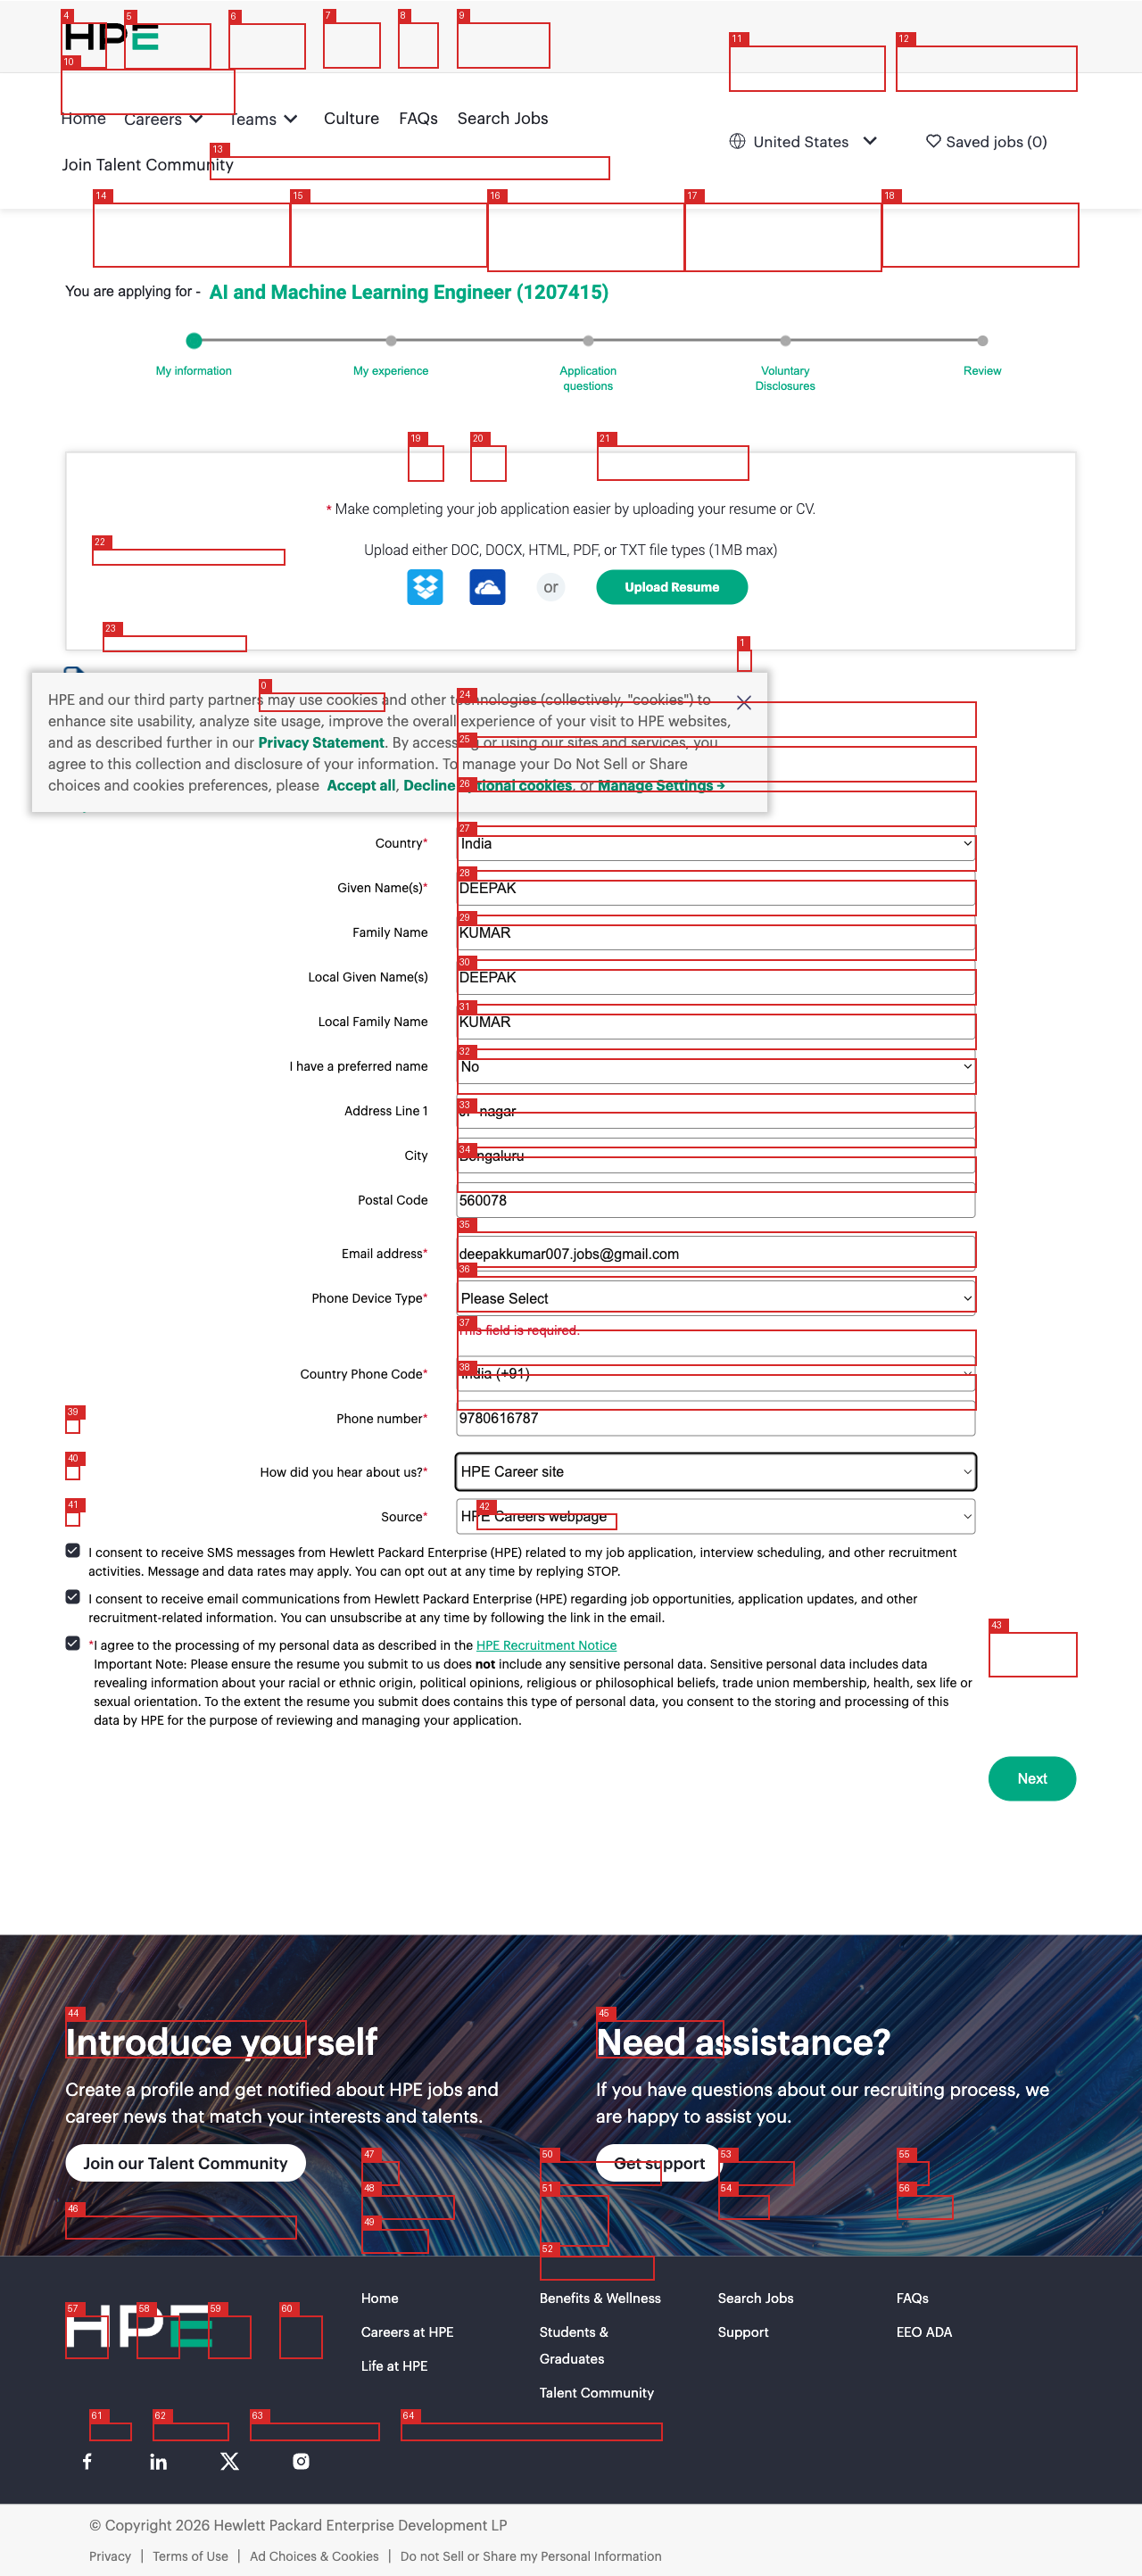

In [97]:
# Full-page screenshot, scroll-aware:
#   1. Scroll to top so getBoundingClientRect coords == document coords
#      (otherwise scrolled-out elements get negative y and the annotator
#      drops them, leaving a misleading half-truth picture for the LLM).
#   2. Re-scan elements at scrollY=0 — boxes now align with the document.
#   3. full_page=True stitches the entire scrollable area into one PNG.
#   4. Annotator draws boxes across the whole document height.
R(page.evaluate("window.scrollTo(0, 0)"))
R(page.wait_for_timeout(400))   # let sticky headers / lazy renders settle
elements, idx_frame = R(collect_elements(page))

raw_png    = R(page.screenshot(full_page=True))
marked_png = annotate_screenshot(raw_png, elements)

# Quick stats so you can see what changed.
from PIL import Image as _PI
import io as _io
_im = _PI.open(_io.BytesIO(raw_png))
print(f"screenshot: {_im.size[0]} x {_im.size[1]} px  ({len(raw_png):,} bytes raw, {len(marked_png):,} bytes marked)")
ys = [e["box"][1] for e in elements if e.get("box")]
print(f"elements: {len(elements)}, y range: {min(ys) if ys else 0} to {max(ys) if ys else 0}")

display(Image(data=marked_png))


## 6. Deterministic field prefill — the Workday cheat code

`workday_prefill()` walks the `_FIELDS` map in [workday.py](workday.py)
(currently: `legalNameSection_firstName`, `legalNameSection_lastName`,
`addressSection_city`, `phone-number`) and fills each by **exact selector**
from your profile. No LLM. No guessing. ~50ms per field.

`workday_fill_dropdowns()` does the same for country / phone-device-type /
phone-country-code, but ONLY when they're still showing the placeholder —
so re-running this cell is safe and idempotent.


In [98]:
USER_ID = 1
profile = load_profile(USER_ID)
print(f"profile.first_name = {profile.get('first_name')!r}")
print(f"profile.last_name  = {profile.get('last_name')!r}")
print(f"profile.city       = {profile.get('city')!r}")
print(f"profile.phone      = {profile.get('phone')!r}")
print(f"profile.country    = {profile.get('country')!r}")
print()

filled_fields = R(workday_prefill(page, profile))
print(f"Fields filled by selector: {filled_fields}")

filled_dropdowns = R(workday_fill_dropdowns(page, profile))
print(f"Dropdowns set:            {filled_dropdowns}")

R(settle(page))


profile.first_name = 'DEEPAK'
profile.last_name  = 'KUMAR'
profile.city       = 'Bengaluru'
profile.phone      = '9780616787'
profile.country    = 'India'

Fields filled by selector: []
Dropdowns set:            []


## 7. Auto-reveal loop — expand multi-row sections
Runs 6c (page overview) and 6d (click Adds) in a loop until either:
- no reveal actions remain (page is fully expanded), OR
- no progress detected (same reveals as last pass -> button is unclickable / maxed out), OR
- MAX_PASSES reached (safety cap).

At the end, the same globals as 6c are set: `last_overview`, `last_row_mappings`, `last_status`, etc. So Step A and Step B just work.


In [99]:
# 6 (auto). Loop 6c -> 6d -> 6c -> 6d until row_mappings populated and
# no more reveal actions are queued. Each pass clicks each queued Add
# ONCE then re-runs the overview, so indices stay fresh and buttons
# that move after a click are re-located via the next 6c pass.

import base64 as _b64
from google import genai as _genai

MAX_PASSES = 6  # safety cap; Workday usually settles in 3-4 passes
_gc_auto = globals().get("gemini_client") or _genai.Client(
    api_key=os.getenv("GEMINI_API_KEY", ""))

def _profile_brief_auto(prof):
    parts = []
    exp = prof.get("experience") or prof.get("work_experience")
    if isinstance(exp, list):
        parts.append(f"{len(exp)} work experiences")
    elif prof.get("current_company"):
        yr = prof.get("years_experience") or "?"
        parts.append(f"current job: {prof.get('current_title','')} @ "
                     f"{prof['current_company']} ({yr} total experience)")
    edu = prof.get("education")
    if isinstance(edu, list):
        parts.append(f"{len(edu)} education entries: " +
                     ", ".join(f"{e.get('degree','?')} {e.get('institution','')}"
                               for e in edu))
    for k in ("certifications", "languages", "skills"):
        v = prof.get(k)
        if isinstance(v, list) and v:
            parts.append(f"{len(v)} {k}")
    return "; ".join(parts) if parts else "minimal profile, no structured lists"

def _build_overview_prompt(brief):
    return f"""Look at this Workday application page. Red numbered boxes mark interactive elements.

USER PROFILE BRIEF: {brief}

Return STRICT JSON only:
{{
  "page_type":  "<login | register | profile | work_experience | education | questions | review | gateway | other>",
  "summary":    "<1-2 sentence overview>",
  "fields":     ["<each visible field with current state>"],
  "buttons":    ["<each visible action button>"],
  "errors":     ["<inline error messages, if any>"],
  "plan":       "<1-2 sentence high-level plan>",
  "status":     "<more_to_fill | ready_to_advance | blocked_validation | submit_review | done>",
  "remaining":  ["<labels of empty REQUIRED fields, empty list if none>"],
  "reveal_actions": [
    {{"index": <int>, "label": "<button label>", "section": "<Work Experience | Education | Certifications | Languages>", "reason": "<why>"}}
  ],
  "row_mappings": [
    {{
      "section":          "<e.g. Work Experience 1 / Education 2 / Certification 3>",
      "profile_list":     "<one of: experience | education | certifications>",
      "profile_index":    <0-based int into that list>,
      "key_value":        "<visible identifying value>",
      "element_indices":  [<list of all red-box numbers that belong to this row>]
    }}
  ]
}}

ROW MAPPINGS: one per visible multi-row container. For EACH visible row
(Work Experience 1, Work Experience 2, Education 1, etc.):
- Identify visible identifying value (company name / institution name).
- Match against profile entries 0-based. Brief lists experience and
  education in order: experience: A, B, C -> A=0, B=1, C=2.
- List EVERY red-box number that belongs to that row.
- If no match in profile brief, set profile_index = -1.
- If no multi-row sections exist, return row_mappings = [].

REVEAL ACTIONS — clicks needed BEFORE filling fields. RETURN EXACTLY ONE
ENTRY PER MISSING ROW (do NOT collapse multiple rows of the same section
into a single 'Add x3' — the loop will re-call you after each click).
- "Add" / "Add Another" / "+ Add" / "Expand all sections": one entry.
- ALWAYS include the SECTION name (Work Experience / Education / etc.)
  to disambiguate identically-labelled buttons across sections.
- If section already shows N rows and brief wants N (or fewer), do NOT
  emit a reveal for that section.
- Do NOT include the page's main 'Save and Continue' / 'Submit' here.

STATUS rules:
- submit_review = LAST page; only button is 'Submit Application'.
- blocked_validation = visible inline errors.
- more_to_fill = any required field still empty.
- ready_to_advance = all required fields filled, has 'Save and Continue'/'Next'.
- done = nothing to do.
"""

def _run_overview_pass():
    """One 6c pass. Returns the parsed overview dict."""
    R(page.evaluate("window.scrollTo(0, 0)"))
    R(page.wait_for_timeout(400))
    elems, idx_fr = R(collect_elements(page))
    raw = R(page.screenshot(full_page=True))
    mark = annotate_screenshot(raw, elems)
    prof = load_profile(globals().get("USER_ID", 1))
    brief = _profile_brief_auto(prof)
    img_b64 = _b64.b64encode(mark).decode()
    ov = llm_json(_build_overview_prompt(brief),
                  image_b64=img_b64,
                  gemini_client=_gc_auto, gemini_model=FLASH_MODEL)
    # Update globals for downstream cells.
    globals()["elements"]            = elems
    globals()["idx_frame"]           = idx_fr
    globals()["marked_png"]          = mark
    globals()["last_overview"]       = ov
    globals()["last_status"]         = ov.get("status", "unknown")
    globals()["last_reveal_actions"] = ov.get("reveal_actions", []) or []
    globals()["last_remaining"]      = ov.get("remaining", []) or []
    globals()["last_row_mappings"]   = ov.get("row_mappings", []) or []
    return ov

def _find_add_button(elems, want_label, want_section):
    """Find the best Add button in `want_section` whose label matches.
    Strategy: prefer button/link tags where label matches AND the element
    APPEARS-AFTER a section-header element whose text contains
    `want_section`. Falls back to label-only match."""
    wl = (want_label or "").strip().lower()
    ws = (want_section or "").strip().lower()
    if not wl:
        return None
    # Map idx -> position in scan order for "appears after" logic.
    pos_of = {e.get("idx"): i for i, e in enumerate(elems)}
    # Locate the most recent section-header element before each Add.
    section_pos = None
    if ws:
        for i, e in enumerate(elems):
            lab = (e.get("label") or "").strip().lower()
            if lab.startswith(ws):
                section_pos = i  # last header wins (the most recent one)
    # Candidate Adds: exact label match + button/link tag.
    cands = [e for e in elems
             if (e.get("label") or "").strip().lower() == wl
             and e.get("tag") in ("button", "a")]
    if not cands:
        cands = [e for e in elems
                 if (e.get("label") or "").strip().lower() == wl]
    if not cands:
        # Last resort: label starts with want_label.
        cands = [e for e in elems
                 if (e.get("label") or "").strip().lower().startswith(wl)
                 and e.get("tag") in ("button", "a")]
    if not cands:
        return None
    # Prefer candidates that appear AFTER the matched section header.
    if section_pos is not None:
        after = [c for c in cands if pos_of.get(c.get("idx"), -1) > section_pos]
        if after:
            # Earliest one after the header is "the Add for this section".
            after.sort(key=lambda c: pos_of.get(c.get("idx"), 10**9))
            return after[0]
    return cands[0]

print("="*72)
print(f"  AUTO-LOOP  (max passes={MAX_PASSES})")
print("="*72)

prev_signature = None
final_overview = None

for _pass in range(1, MAX_PASSES + 1):
    print(f"\n--- pass {_pass} : overview ---")
    ov = _run_overview_pass()
    final_overview = ov
    reveals = ov.get("reveal_actions") or []
    rows    = ov.get("row_mappings") or []
    status  = ov.get("status", "unknown")
    print(f"  status={status}   rows={len(rows)}   reveals={len(reveals)}")
    if rows:
        for rm in rows[:8]:
            print(f"    row: {rm.get('section','?'):28} -> "
                  f"{rm.get('profile_list','?')}[{rm.get('profile_index')}]  "
                  f"boxes={rm.get('element_indices') or []}")

    # ---- DETERMINISTIC count-based reveal generator ----
    # The LLM sometimes returns reveals=[] even when profile has more
    # entries than rows visible (because validation errors on the empty
    # row make it cautious). Trust profile counts vs row_mappings count.
    _prof_now = load_profile(globals().get("USER_ID", 1))
    SECTION_HEADER_HINT = {
        "experience":     ("Work Experience", ("Add", "Add Another", "+ Add")),
        "education":      ("Education",       ("Add", "Add Another", "+ Add")),
        "certifications": ("Certification",   ("Add", "Add Another", "+ Add")),
    }
    # Count visible rows by scanning DOM-baked section_labels on `elements`.
    # Replaces the old read of 6c's row_mappings (LLM-driven, unreliable).
    import re as _re_cnt
    _SEC_PAT = _re_cnt.compile(
        r"(Work Experience|Employment|Education|Certifications?|Languages?)\s+(\d+)",
        _re_cnt.I)
    _SEC_TO_LIST = {
        "work experience":  "experience",
        "employment":       "experience",
        "education":        "education",
        "certification":    "certifications",
        "certifications":   "certifications",
        "language":         "languages",
        "languages":        "languages",
    }
    _elems_now = globals().get("elements") or []
    _seen_by_list = {}
    for _e in _elems_now:
        _sl = (_e.get("section_label") or "").strip()
        if not _sl:
            continue
        _m = _SEC_PAT.search(_sl)
        if not _m:
            continue
        _w = _m.group(1).lower()
        _list = _SEC_TO_LIST.get(_w) or _SEC_TO_LIST.get(_w.rstrip("s"))
        if _list:
            _seen_by_list.setdefault(_list, set()).add(_sl)
    visible_count = {k: len(v) for k, v in _seen_by_list.items()}
    auto_reveals = []
    for plist, (hdr_hint, add_labels) in SECTION_HEADER_HINT.items():
        entries = _prof_now.get(plist) or []
        want, have = len(entries), visible_count.get(plist, 0)
        if want > have:
            auto_reveals.append({
                "section":      hdr_hint,
                "add_labels":   add_labels,
                "needed":       want - have,
            })
            print(f"  [counts] profile.{plist}: want={want} have={have}"
                  f" -> need {want - have} more Add click(s) in '{hdr_hint}'")

    if not reveals and not auto_reveals:
        print("  -> no reveals queued and counts match, exiting loop")
        break

    # No-progress detector: same reveals as last pass -> stuck.
    sig = tuple(sorted(
        ((r.get("label") or "").lower(),
         (r.get("section") or "").lower())
        for r in reveals
    ))
    if sig == prev_signature:
        print("  -> SAME reveals as previous pass, no progress; stopping")
        break
    prev_signature = sig

    print(f"  clicking {len(reveals)} reveal(s):")
    creds = {"email": os.getenv("APPLY_EMAIL", ""),
             "password": os.getenv("APPLY_PASSWORD", "")}
    elems_cur = globals().get("elements") or []
    idx_fr_cur = globals().get("idx_frame")
    for rev in reveals:
        label   = rev.get("label", "?")
        section = rev.get("section", "")
        target  = _find_add_button(elems_cur, label, section)
        if target is None:
            print(f"    SKIP '{label}' in '{section}' -> not found in elements")
            continue
        aidx = target["idx"]
        print(f"    click [{aidx}] '{target.get('label')}'  (section='{section}')")
        try:
            ok, note = R(execute_action(
                page, {"action": "click", "index": aidx},
                idx_fr_cur, elems_cur, "", creds,
            ))
            print(f"        {'OK ' if ok else 'FAIL'} {note}")
        except Exception as e:
            print(f"        FAIL {type(e).__name__}: {e}")
            continue
        R(settle(page))
        # Re-scan after each click for the next reveal's lookup.
        elems_cur, idx_fr_cur = R(collect_elements(page))
        globals()["elements"]  = elems_cur
        globals()["idx_frame"] = idx_fr_cur

    # Deterministic clicks based on profile-count gap. Click ONE per section
    # per pass; next pass picks up the next one. Stops cross-wiring because
    # we scope by section header.
    for ar in auto_reveals:
        hdr_hint = ar["section"]
        clicked  = False
        for lab in ar["add_labels"]:
            tgt = _find_add_button(elems_cur, lab, hdr_hint)
            if tgt is not None:
                aidx2 = tgt["idx"]
                print(f"  [counts-add] click [{aidx2}] '{tgt.get('label')}'  "
                      f"(section='{hdr_hint}')")
                try:
                    ok, note = R(execute_action(
                        page, {"action": "click", "index": aidx2},
                        idx_fr_cur, elems_cur, "", creds,
                    ))
                    print(f"            {'OK ' if ok else 'FAIL'} {note}")
                    R(settle(page))
                    elems_cur, idx_fr_cur = R(collect_elements(page))
                    globals()["elements"]  = elems_cur
                    globals()["idx_frame"] = idx_fr_cur
                    clicked = True
                except Exception as e:
                    print(f"            FAIL {type(e).__name__}: {e}")
                break
        if not clicked:
            print(f"  [counts-add] no Add button found for '{hdr_hint}' "
                  f"(tried labels: {ar['add_labels']})")
else:
    print(f"\n  reached MAX_PASSES ({MAX_PASSES}); stopping")

print("\n" + "="*72)
print("  AUTO-LOOP DONE")
print(f"  Final status        : {globals().get('last_status')}")
print(f"  Final row_mappings  : {len(globals().get('last_row_mappings') or [])} row(s)")
print(f"  Remaining required  : {len(globals().get('last_remaining') or [])}")
print("="*72)

# Final state ready: Step A and Step B can run on these globals as-is.


  AUTO-LOOP  (max passes=6)

--- pass 1 : overview ---
  status=blocked_validation   rows=0   reveals=0
  [counts] profile.experience: want=3 have=0 -> need 3 more Add click(s) in 'Work Experience'
  [counts] profile.education: want=2 have=0 -> need 2 more Add click(s) in 'Education'
  clicking 0 reveal(s):
  [counts-add] no Add button found for 'Work Experience' (tried labels: ('Add', 'Add Another', '+ Add'))
  [counts-add] no Add button found for 'Education' (tried labels: ('Add', 'Add Another', '+ Add'))

--- pass 2 : overview ---
  status=blocked_validation   rows=0   reveals=0
  [counts] profile.experience: want=3 have=0 -> need 3 more Add click(s) in 'Work Experience'
  [counts] profile.education: want=2 have=0 -> need 2 more Add click(s) in 'Education'
  -> SAME reveals as previous pass, no progress; stopping

  AUTO-LOOP DONE
  Final status        : blocked_validation
  Final row_mappings  : 0 row(s)
  Remaining required  : 1


## 8. Convergence fill — the fill engine (apply_engine.py)

Thin driver over `apply_engine.converge_page()`. The engine fills every field from the profile (section-aware, deterministic), clicks Save & Continue, and uses the page's own validation errors as the to-do list — clearing and refilling exactly the fields that error until the page advances or a field needs you. Handles dropdown semantic-mapping (cached), dates, resume upload, phantom-row delete, gateway 'Apply Manually', and auth submit.

Run order per page: **4 (scan) → 7 (reveal rows) → 8 (this)**.


In [100]:
# Convergence fill — the engine lives in apply_engine.py (one reusable module).
# This cell is a thin driver: it just calls converge_page() and updates `page`.
from google import genai as _genai
import apply_engine
from apply_engine import converge_page, resolve_field   # resolve_field = held-dropdown helper

_gc = globals().get("gemini_client") or _genai.Client(api_key=os.getenv("GEMINI_API_KEY", ""))
profile = load_profile(globals().get("USER_ID", 1))

_result = R(converge_page(page, ctx, profile,
                          user_id=globals().get("USER_ID", 1),
                          gemini_client=_gc, max_attempts=6))
# converge_page may switch tabs — adopt whatever page it ended on.
page = _result["page"]
print()
print(f"result: {_result['status']}   url: {_result['url']}")
if _result.get("held"):
    print("Held fields awaiting your confirm — run the resolve_field(...) line(s) above,")
    print("then call save_profile(USER_ID, profile) and re-run this cell.")


  CONVERGE PAGE   (max 6 attempts)   resume=True

--- attempt 1 ---
  filled 1; 2 no-data; 0 fail; 0 held
    OK   [21] Upload Resume [upload]
    --   [5] Careers (no profile value)
    --   [6] Teams (no profile value)
  advance: clicked (text-advance 'Next')

[!] 3 blocking error(s):
    [ 24] ''                                     Please enter all required fields: Please enter all required fields: This field is required.
    [ 34] ''                                     Phone Device Type * Please Select Dormitory Home Main Other Pager 1 Pager 2 Personal Mobile This field is required.
    [ 34] ''                                     This field is required.

  correcting errored fields:
  (no errored field located to correct)
  -> corrected 0 field(s)

--- attempt 2 ---
  filled 0; 2 no-data; 0 fail; 0 held
    --   [5] Careers (no profile value)
    --   [6] Teams (no profile value)
  advance: clicked (text-advance 'Next')

[!] 3 blocking error(s):
    [ 24] ''                       

## 9. Cleanup

Close the browser. Skip if you want to keep poking at the page manually.


In [101]:
# R(ctx.close())
# R(_p.stop())
# print("Closed.")
